# [투자전략] 연금저축 600만 원 꼭 필요할까? 월 14만 원으로 55세 연금 125만 원 만들기

조건을 입력하고 아래 코드 셀을 실행하세요. 시작연도별 최소 생존 원금을 그래프로 표시합니다.

연금 개시 자산은 12개월 동안 QQQ에 분할매수합니다. 매수 전 자금은 원화 단기 금융상품에 보관하고 CD 91일물 금리를 적용하며, 매월 필요한 매수액만 달러로 환전합니다.

In [11]:
# @title 연금저축 주요 제도 표를 표시하세요
import pandas as pd
from IPython.display import HTML, display

pension_rules = pd.DataFrame(
    [
        ("연간 납입한도", "1,800만 원", "전 금융기관 합산"),
        ("세액공제 한도", "연 600만 원", "IRP 포함 최대 900만 원"),
        ("세액공제율", "13.2% 또는 16.5%", "총급여 5,500만 원 기준"),
        ("투자 가능 상품", "국내 상장 ETF, 펀드 등", "미국주식·ETF 직접투자 불가"),
        ("운용 혜택", "과세이연 (복리 효과)", "인출 전까지 배당·차익 세금 0원"),
        ("연금 개시", "만 55세 이후 + 가입 5년", "계좌별 개시 가능"),
        ("연금소득세", "3.3~5.5%", "연 1,500만 원 이하 저율과세¹"),
        ("중도인출", "가능", "세액공제 미수령 원금 비과세, 그 외 16.5%"),
    ],
    columns=["구분", "내용", "비고"],
)
table_html = pension_rules.to_html(
    index=False, border=0, classes="pension-rule-table", escape=True
)
display(HTML("""
<style>
.rule-section{max-width:700px;font-family:Pretendard,-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif}
.rule-brand{margin:0 0 5px;color:#64748b;font-size:13px}
.rule-title{margin:0 0 4px;color:#0f172a;font-size:20px;font-weight:700}
.rule-caption{margin:0 0 14px;color:#64748b;font-size:13px}
.rule-wrap{overflow:hidden;border:1px solid #f0f2f5;border-radius:12px}
.rule-footnote{margin:10px 0 0;color:#64748b;font-size:13px;line-height:1.5}
.pension-rule-table{width:100%;table-layout:fixed;border-collapse:separate;border-spacing:0;font-size:13px;color:#1e293b}
.pension-rule-table th{padding:11px 3px;background:#2b4a75;color:white;font-weight:700;text-align:center}
.pension-rule-table td{padding:11px 8px;border-bottom:1px solid #f0f2f5;line-height:1.45;text-align:center}
.pension-rule-table tbody tr:nth-child(even) td{background:#fafbfc}
.pension-rule-table tbody tr:last-child td{border-bottom:0}
.pension-rule-table td:first-child{font-weight:600}
.pension-rule-table td:nth-child(3){color:#64748b}
.pension-rule-table th:nth-child(1){width:24%}
.pension-rule-table th:nth-child(2){width:31%}
.pension-rule-table th:nth-child(3){width:45%}
</style>
<section class="rule-section">
<p class="rule-brand">대도시 연구실</p>
<h2 class="rule-title">연금저축 핵심 정리</h2>
<p class="rule-caption">납입부터 연금 수령까지 주요 조건</p>
<div class="rule-wrap">""" + table_html + """</div>
<p class="rule-footnote">¹ 연금소득세율: 만 55~69세 5.5%, 만 70~79세 4.4%, 만 80세 이상 3.3% 적용. 과세대상 사적연금이 연 1,500만 원을 초과하면 16.5% 분리과세 또는 종합과세 선택.</p>
</section>
"""))


구분,내용,비고
연간 납입한도,"1,800만 원",전 금융기관 합산
세액공제 한도,연 600만 원,IRP 포함 최대 900만 원
세액공제율,13.2% 또는 16.5%,"총급여 5,500만 원 기준"
투자 가능 상품,"국내 상장 ETF, 펀드 등",미국주식·ETF 직접투자 불가
운용 혜택,과세이연 (복리 효과),인출 전까지 배당·차익 세금 0원
연금 개시,만 55세 이후 + 가입 5년,계좌별 개시 가능
연금소득세,3.3~5.5%,"연 1,500만 원 이하 저율과세¹"
중도인출,가능,"세액공제 미수령 원금 비과세, 그 외 16.5%"


## 필요한 최소 준비금

**1억 6,600만원**

2002~2016년 어느 해에 시작해도 2026년 7월까지 고갈되지 않았던 금액입니다. 가장 불리했던 시작연도는 **2002년**입니다.

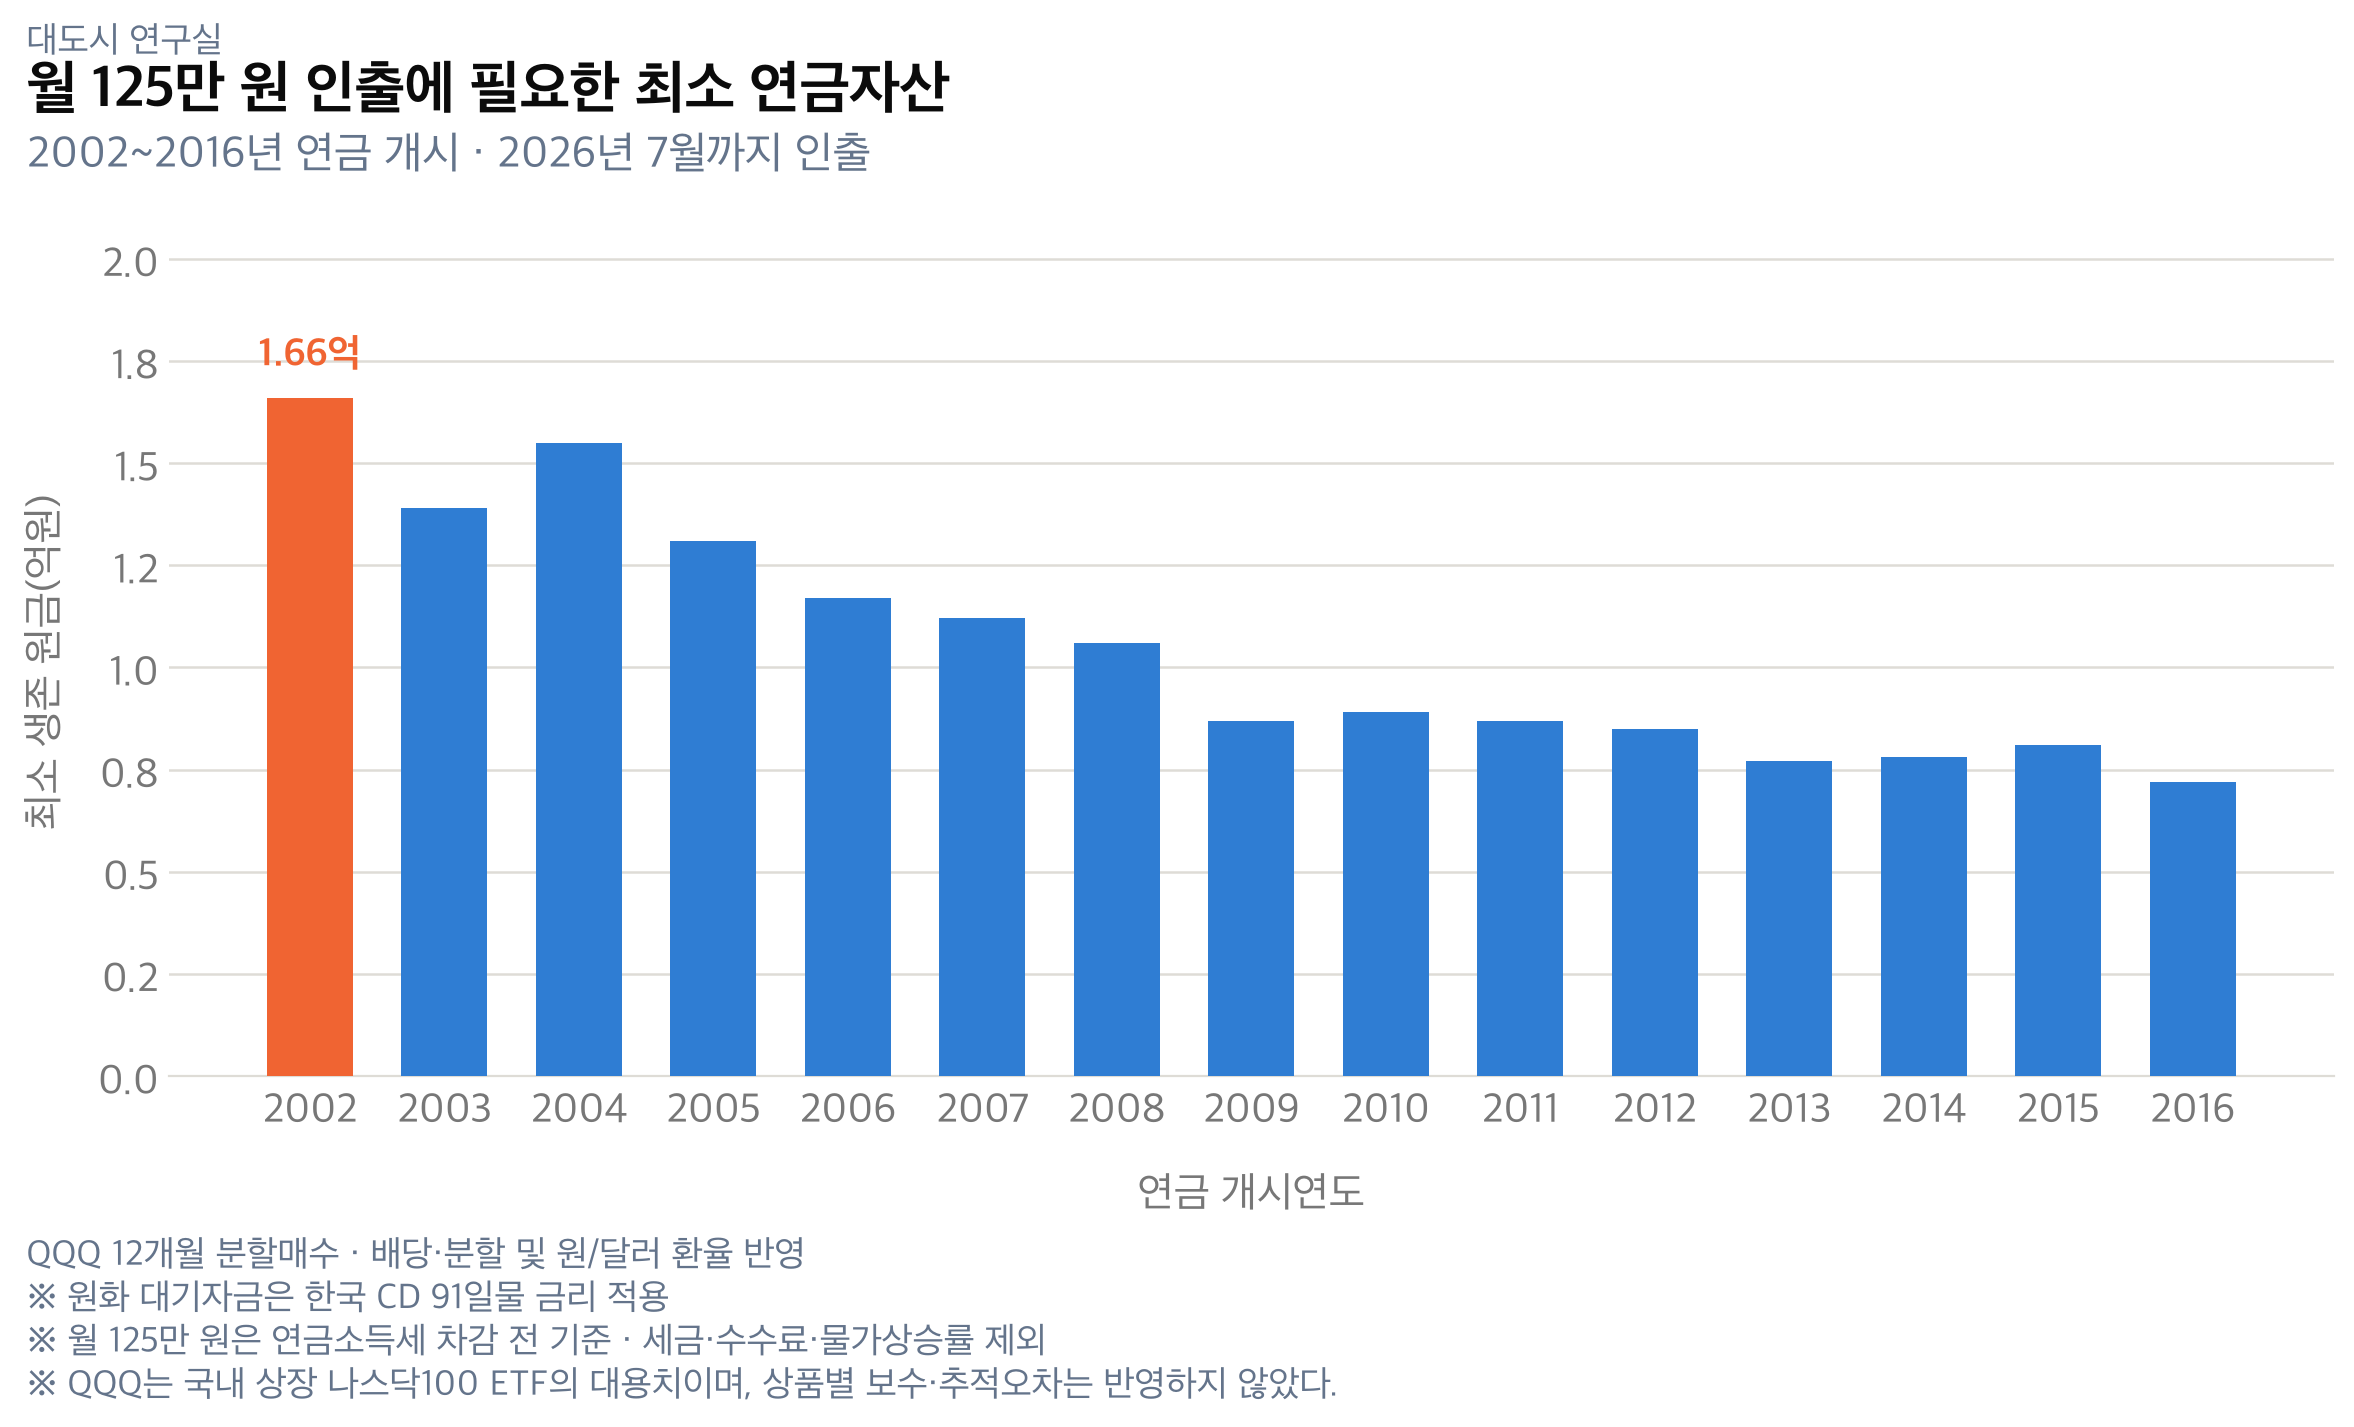

**시작연도별 최소 연금자산 평균: 1억 547만원**

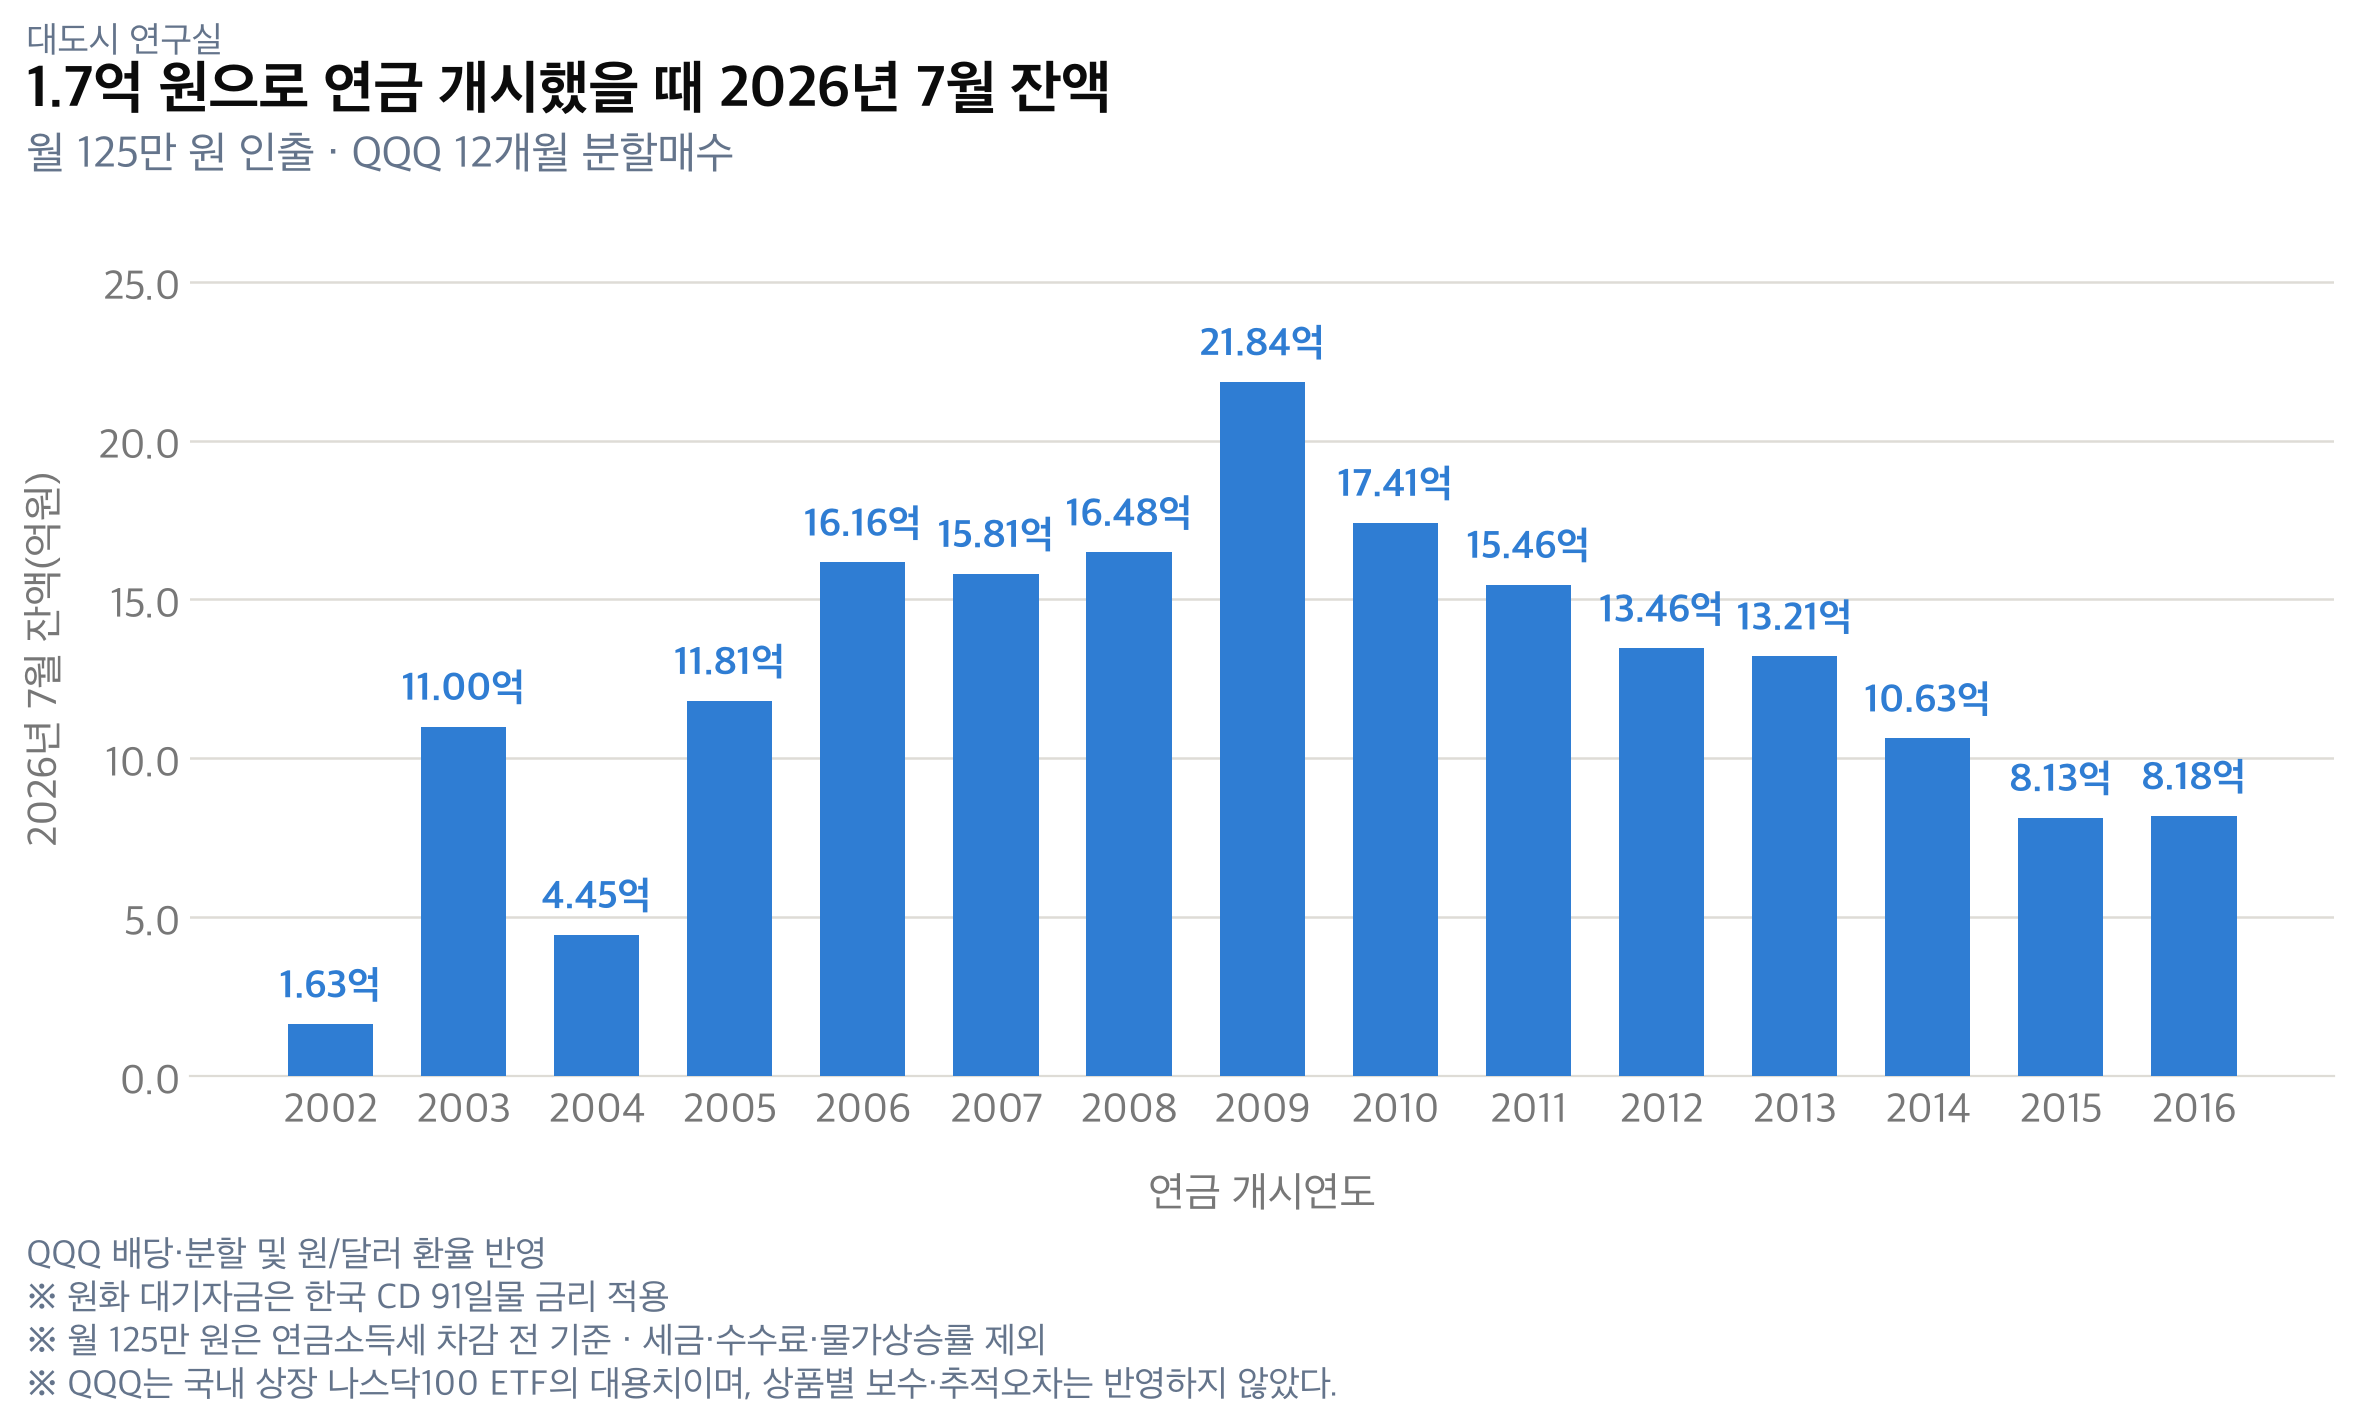

**시작연도별 2026년 7월 잔액 평균: 12억 3,771만원**

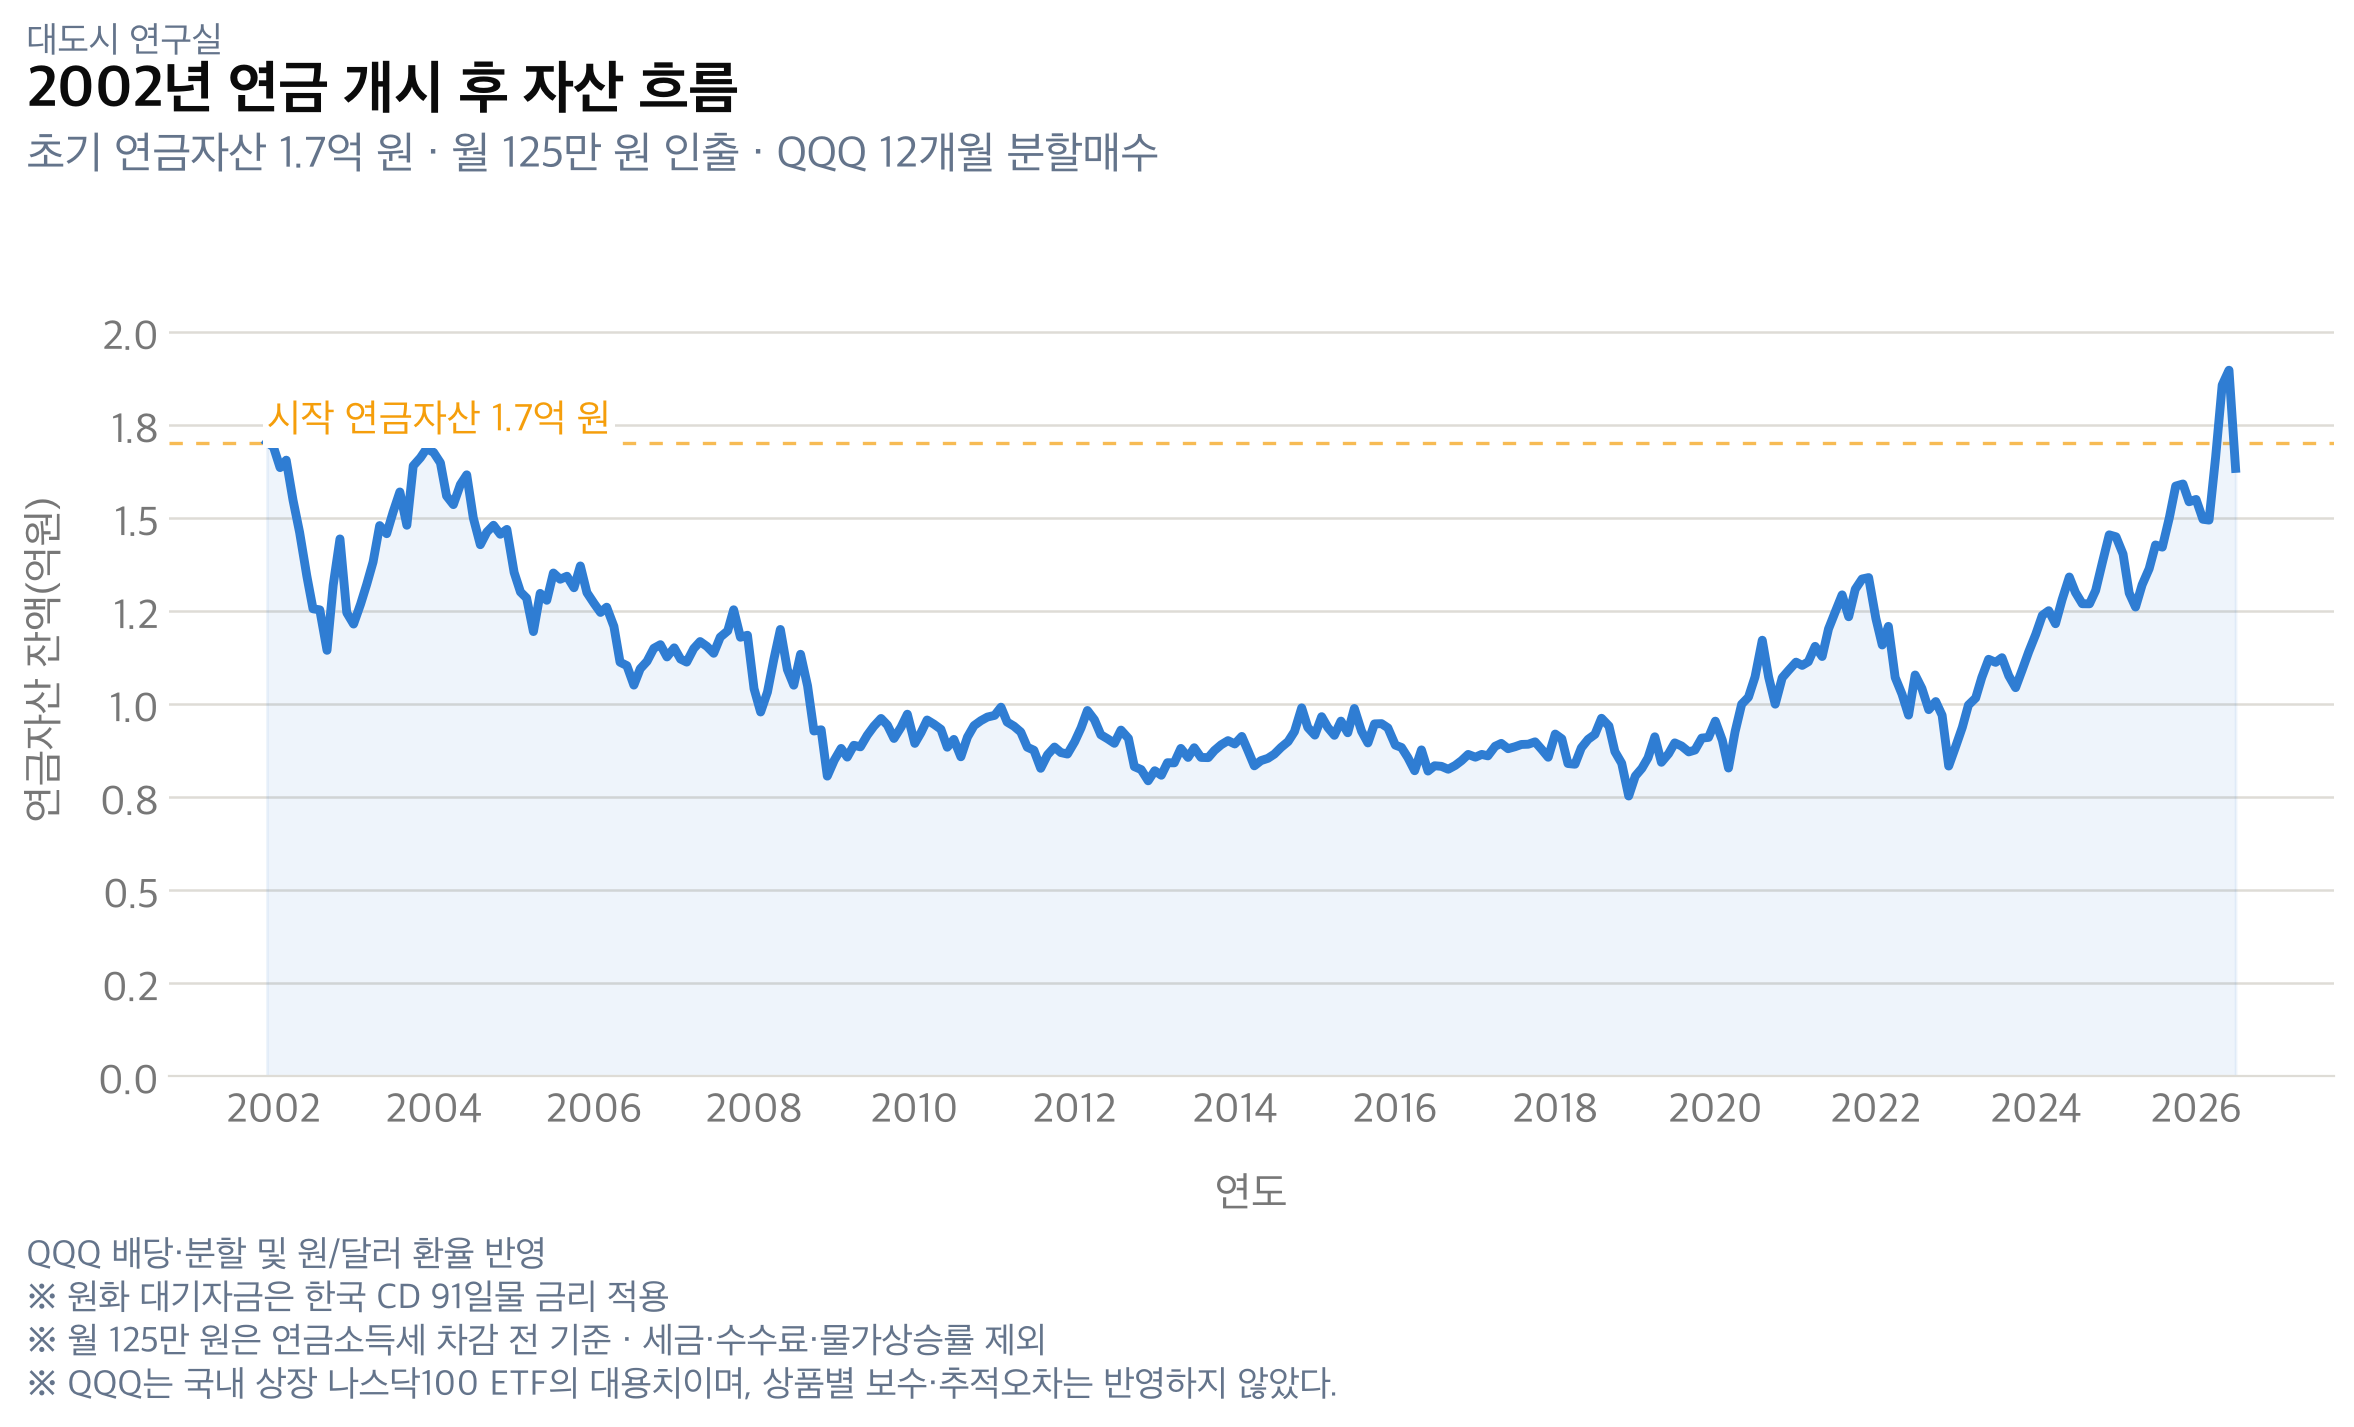

In [12]:
# @title 연금 인출 조건을 입력하고 실행하세요
최초_시작연도 = 2002  # @param {type:"integer", min:2000, max:2026, step:1}
마지막_시작연도 = 2016  # @param {type:"integer", min:2000, max:2026, step:1}
분석_종료연도 = 2026  # @param {type:"integer", min:2000, max:2026, step:1}
분석_종료월 = 7  # @param {type:"integer", min:1, max:12, step:1}
월인출액_만원 = 125  # @param {type:"number", min:1, step:5}
초기연금자산_억원 = 1.7  # @param {type:"number", min:0.1, step:0.1}
분할매수기간_개월 = 12  # @param {type:"integer", min:1, max:24, step:1}

"""QQQ와 원/달러 환율로 시작연도별 최소 생존 원금을 계산한다.

QQQ 수정주가는 Yahoo Finance, 원/달러 환율은 미국 연준 FRED의
DEXKOUS, 원화 대기자금 수익률은 한국은행 ECOS의 CD 91일물 월별
금리를 사용한다. 연금 개시 전월부터 입력한 기간 동안 QQQ를 분할매수하며,
매월 첫 거래일에 세전 인출액을 원화로 인출한 뒤 필요한 매수액만
달러로 환전한다.
"""

import json
import math
import os
from pathlib import Path
import subprocess
import sys
from typing import Any, cast
from urllib.request import urlopen, urlretrieve

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib import font_manager
import pandas as pd
from IPython.display import Image, Markdown, display

IS_COLAB = bool(os.environ.get("COLAB_RELEASE_TAG")) or Path("/content").exists()
OUTPUT_DIR = Path("/content/output") if IS_COLAB else Path("output")
TICKER = "QQQ"
FIRST_START_YEAR = int(최초_시작연도)
LAST_START_YEAR = int(마지막_시작연도)
END_YEAR = int(분석_종료연도)
END_MONTH = int(분석_종료월)
END_PERIOD = pd.Period(year=END_YEAR, month=END_MONTH, freq="M")
END_LABEL = f"{END_YEAR}년 {END_MONTH}월"
WON_PER_MANWON = 10_000
WON_PER_EOK = 100_000_000
RESERVE_ROUNDING_KRW = 1_000_000
MONTHLY_WITHDRAWAL_KRW = float(월인출액_만원) * WON_PER_MANWON
INITIAL_PENSION_ASSET_KRW = float(초기연금자산_억원) * WON_PER_EOK
INSTALLMENT_MONTHS = int(분할매수기간_개월)
MONTHS_PER_YEAR = 12

try:
    import yfinance as yf
except ImportError:
    if not IS_COLAB:
        raise
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])
    import yfinance as yf


def validate_parameters() -> None:
    """입력한 연도와 인출액을 검증한다."""
    if FIRST_START_YEAR < 2000:
        raise ValueError("QQQ 데이터 범위를 고려해 2000년 이후로 입력하세요.")
    if FIRST_START_YEAR > LAST_START_YEAR:
        raise ValueError("최초 시작연도는 마지막 시작연도보다 늦을 수 없습니다.")
    if LAST_START_YEAR > END_YEAR:
        raise ValueError("마지막 시작연도는 분석 종료연도보다 늦을 수 없습니다.")
    if not 1 <= END_MONTH <= 12:
        raise ValueError("분석 종료월은 1~12월이어야 합니다.")
    if MONTHLY_WITHDRAWAL_KRW <= 0:
        raise ValueError("월 인출액은 0보다 커야 합니다.")
    if INITIAL_PENSION_ASSET_KRW <= 0:
        raise ValueError("초기 연금자산은 0보다 커야 합니다.")
    if not 1 <= INSTALLMENT_MONTHS <= 24:
        raise ValueError("분할매수 기간은 1~24개월이어야 합니다.")


def download_prices() -> pd.Series:
    """Yahoo Finance에서 QQQ 일별 수정주가를 내려받는다."""
    download_end = (END_PERIOD + 1).to_timestamp() + pd.Timedelta(days=9)
    raw = yf.download(
        TICKER, start=f"{FIRST_START_YEAR - 1}-12-01",
        end=download_end.strftime("%Y-%m-%d"), auto_adjust=False,
        progress=False, actions=False,
    )
    if raw is None or raw.empty:
        raise RuntimeError("QQQ 가격 데이터를 내려받지 못했습니다.")
    prices = raw["Adj Close"]
    if isinstance(prices, pd.DataFrame):
        frame = cast(pd.DataFrame, prices)
        prices = frame[TICKER] if TICKER in frame.columns else frame.iloc[:, 0]
    prices = prices.dropna().astype(float)
    prices.index = pd.to_datetime(prices.index).tz_localize(None).normalize()
    return prices


def download_usdkrw() -> pd.Series:
    """FRED에서 일별 원/달러 환율을 내려받는다."""
    end_date = END_PERIOD.to_timestamp(how="end").strftime("%Y-%m-%d")
    url = (
        "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXKOUS"
        f"&cosd={FIRST_START_YEAR - 1}-12-01&coed={end_date}"
    )
    raw = pd.read_csv(url)
    date_column = "observation_date" if "observation_date" in raw.columns else "DATE"
    dates = pd.to_datetime(raw[date_column])
    values = pd.to_numeric(raw["DEXKOUS"], errors="coerce")
    return pd.Series(values.to_numpy(), index=dates, name="usdkrw").dropna()


def download_monthly_cd91_rates() -> pd.Series:
    """월별 CD 91일물 금리를 한국은행 ECOS에서 내려받는다."""
    start = f"{FIRST_START_YEAR - 1}11"
    end = f"{END_YEAR}{END_MONTH:02d}"
    base_url = "https://ecos.bok.or.kr/api/StatisticSearch/sample/json/kr"

    def request_rows(start_row: int, end_row: int) -> dict[str, Any]:
        url = (
            f"{base_url}/{start_row}/{end_row}/721Y001/M/"
            f"{start}/{end}/2010000"
        )
        with urlopen(url, timeout=30) as response:
            payload = json.load(response)
        if "StatisticSearch" not in payload:
            message = payload.get("RESULT", {}).get(
                "MESSAGE", "알 수 없는 ECOS 오류"
            )
            raise RuntimeError(
                f"CD 91일물 금리를 받지 못했습니다: {message}"
            )
        return payload["StatisticSearch"]

    first_page = request_rows(1, 10)
    total_count = int(first_page["list_total_count"])
    rows = list(first_page["row"])
    for start_row in range(11, total_count + 1, 10):
        end_row = min(start_row + 9, total_count)
        rows.extend(request_rows(start_row, end_row)["row"])

    dates = pd.to_datetime(
        [row["TIME"] for row in rows], format="%Y%m"
    ).to_period("M")
    values = pd.to_numeric(
        [row["DATA_VALUE"] for row in rows], errors="coerce"
    )
    return pd.Series(
        values, index=dates, name="cd91_rate_percent"
    ).dropna()


def prepare_monthly_data(
    prices: pd.Series, fx_rates: pd.Series, cd91_rates: pd.Series
) -> pd.DataFrame:
    """매월 첫 QQQ 거래일 가격·환율과 직전 월 CD 금리를 결합한다."""
    daily = pd.DataFrame({
        "price": prices,
        "usdkrw": fx_rates.reindex(prices.index, method="ffill"),
    }).dropna()
    daily["date"] = daily.index
    daily["month"] = daily.index.to_period("M")
    monthly = daily.groupby("month", sort=True).agg(
        date=("date", "first"),
        price=("price", "first"),
        usdkrw=("usdkrw", "first"),
        ending_price=("price", "last"),
        ending_usdkrw=("usdkrw", "last"),
    )
    monthly["cd91_rate_percent"] = cd91_rates.reindex(monthly.index)
    monthly["previous_cd91_rate_percent"] = cd91_rates.reindex(
        monthly.index - 1
    ).to_numpy()
    return monthly


def round_up_reserve(amount_krw: float) -> float:
    """준비금을 100만원 단위로 올림한다."""
    return math.ceil(amount_krw / RESERVE_ROUNDING_KRW) * RESERVE_ROUNDING_KRW


def simulate_pension_withdrawal(
    monthly: pd.DataFrame, start_year: int, initial_asset_krw: float
) -> tuple[dict[str, Any], pd.DataFrame]:
    """원화 대기자금과 분할매수를 반영해 월별 인출을 계산한다."""
    trade_month = pd.Period(f"{start_year - 1}-12", freq="M")
    final_month = END_PERIOD
    period = monthly.loc[trade_month:final_month]
    withdrawal_months = (END_YEAR - start_year) * MONTHS_PER_YEAR + END_MONTH
    expected_months = withdrawal_months + 1
    if len(period) != expected_months or period.isna().any().any():
        raise RuntimeError(
            f"{start_year}년: 분할매수·인출 데이터 {expected_months}개가 "
            f"필요하지만 {len(period)}개만 확인됐습니다."
        )

    cash_krw = float(initial_asset_krw)
    shares = 0.0
    base_installment_krw = initial_asset_krw / INSTALLMENT_MONTHS
    installment_count = 0
    total_withdrawn_krw = 0.0
    total_waiting_interest_krw = 0.0
    depletion_month = "-"
    rows = []

    for month_number, (month, values) in enumerate(period.iterrows()):
        price_usd = float(values["price"])
        fx_rate = float(values["usdkrw"])
        cash_interest_krw = 0.0
        if month_number > 0:
            monthly_cd91_rate = (
                float(values["previous_cd91_rate_percent"])
                / 100
                / MONTHS_PER_YEAR
            )
            cash_interest_krw = cash_krw * monthly_cd91_rate
            cash_krw += cash_interest_krw
            total_waiting_interest_krw += cash_interest_krw

        actual_withdrawal_krw = 0.0
        if month_number > 0:
            cash_withdrawal_krw = min(cash_krw, MONTHLY_WITHDRAWAL_KRW)
            cash_krw -= cash_withdrawal_krw
            remaining_withdrawal_krw = (
                MONTHLY_WITHDRAWAL_KRW - cash_withdrawal_krw
            )
            equity_krw = shares * price_usd * fx_rate
            equity_withdrawal_krw = min(
                remaining_withdrawal_krw, equity_krw
            )
            shares -= equity_withdrawal_krw / (price_usd * fx_rate)
            actual_withdrawal_krw = (
                cash_withdrawal_krw + equity_withdrawal_krw
            )
            total_withdrawn_krw += actual_withdrawal_krw
            if actual_withdrawal_krw + 0.5 < MONTHLY_WITHDRAWAL_KRW:
                depletion_month = str(month)

        purchase_krw = 0.0
        if depletion_month == "-" and installment_count < INSTALLMENT_MONTHS:
            purchase_krw = min(base_installment_krw, cash_krw)
            cash_krw -= purchase_krw
            shares += purchase_krw / (price_usd * fx_rate)
            installment_count += 1

        ending_equity_krw = shares * float(values["ending_price"]) * float(
            values["ending_usdkrw"]
        )
        ending_balance_krw = cash_krw + ending_equity_krw
        rows.append({
            "date": pd.Timestamp(values["date"]),
            "month_number": month_number,
            "cd91_rate_percent": float(values["cd91_rate_percent"]),
            "cash_interest_krw": cash_interest_krw,
            "actual_withdrawal_krw": actual_withdrawal_krw,
            "purchase_krw": purchase_krw,
            "ending_cash_krw": cash_krw,
            "ending_equity_krw": ending_equity_krw,
            "ending_balance_krw": ending_balance_krw,
        })
        if depletion_month != "-":
            break

    survived = (
        depletion_month == "-"
        and len(rows) == expected_months
        and total_withdrawn_krw + 0.5
        >= withdrawal_months * MONTHLY_WITHDRAWAL_KRW
    )
    result = {
        "survived": survived,
        "depletion_month": depletion_month,
        "total_withdrawn_krw": total_withdrawn_krw,
        "total_waiting_interest_krw": total_waiting_interest_krw,
        "ending_balance_krw": float(rows[-1]["ending_balance_krw"]),
    }
    return result, pd.DataFrame(rows)


def find_required_reserve(monthly: pd.DataFrame, start_year: int) -> float:
    """분할매수 조건에서 전 기간 인출 가능한 최소 원금을 찾는다."""
    lower_krw = 0.0
    upper_krw = INITIAL_PENSION_ASSET_KRW
    result, _ = simulate_pension_withdrawal(
        monthly, start_year, upper_krw
    )
    while not result["survived"]:
        upper_krw *= 2
        result, _ = simulate_pension_withdrawal(
            monthly, start_year, upper_krw
        )
    for _ in range(60):
        middle_krw = (lower_krw + upper_krw) / 2
        result, _ = simulate_pension_withdrawal(
            monthly, start_year, middle_krw
        )
        if result["survived"]:
            upper_krw = middle_krw
        else:
            lower_krw = middle_krw
    return upper_krw


def calculate_required_reserves(monthly: pd.DataFrame) -> pd.DataFrame:
    """각 시작연도부터 종료연도까지 필요한 최소 원금을 계산한다."""
    rows = []
    for start_year in range(FIRST_START_YEAR, LAST_START_YEAR + 1):
        exact_reserve_krw = find_required_reserve(monthly, start_year)
        initial_result, _ = simulate_pension_withdrawal(
            monthly, start_year, INITIAL_PENSION_ASSET_KRW
        )
        rows.append({
            "start_year": start_year,
            "withdrawal_months": (
                (END_YEAR - start_year) * MONTHS_PER_YEAR + END_MONTH
            ),
            "total_withdrawal_krw": (
                ((END_YEAR - start_year) * MONTHS_PER_YEAR + END_MONTH)
                * MONTHLY_WITHDRAWAL_KRW
            ),
            "exact_reserve_krw": exact_reserve_krw,
            "required_reserve_krw": round_up_reserve(
                exact_reserve_krw
            ),
            "depleted_with_initial_asset": not initial_result["survived"],
            "depletion_month_with_initial_asset": initial_result["depletion_month"],
            "ending_balance_with_initial_asset_krw": initial_result["ending_balance_krw"],
            "waiting_interest_with_initial_asset_krw": initial_result["total_waiting_interest_krw"],
        })
    return pd.DataFrame(rows)


def calculate_balance_flow(monthly: pd.DataFrame, start_year: int) -> pd.DataFrame:
    """분할매수와 월초 인출을 반영한 초기 연금자산 잔액을 계산한다."""
    _, balance_flow = simulate_pension_withdrawal(
        monthly, start_year, INITIAL_PENSION_ASSET_KRW
    )
    return balance_flow


def format_korean_currency(amount: float) -> str:
    """원화 금액을 억원과 만원 단위로 표시한다."""
    eok, manwon = divmod(int(round(amount / WON_PER_MANWON)), 10_000)
    if eok and manwon:
        return f"{eok:,}억 {manwon:,}만원"
    return f"{eok:,}억원" if eok else f"{manwon:,}만원"


FONT_CANDIDATES = ("Pretendard", "Apple SD Gothic Neo", "Noto Sans CJK KR", "Malgun Gothic")
COLAB_FONT_PATH = Path("/content/.fonts/Pretendard-Regular.otf")
COLAB_FONT_URL = ("https://raw.githubusercontent.com/orioncactus/pretendard/main/"
                  "packages/pretendard/dist/public/static/Pretendard-Regular.otf")
BLUE, ORANGE = "#2F7DD3", "#F06432"
TEXT_COLOR, SECONDARY_TEXT_COLOR = "#0B0B0B", "#64748B"
TICK_COLOR, GRID_COLOR, BACKGROUND_COLOR = "#777777", "#DEDCD6", "#FFFFFF"


def configure_korean_font() -> None:
    """사용 가능한 한글 글꼴을 Matplotlib에 설정한다."""
    installed = {font.name for font in font_manager.fontManager.ttflist}
    font_name = next((name for name in FONT_CANDIDATES if name in installed), None)
    if font_name is None and IS_COLAB:
        COLAB_FONT_PATH.parent.mkdir(parents=True, exist_ok=True)
        if not COLAB_FONT_PATH.exists():
            urlretrieve(COLAB_FONT_URL, COLAB_FONT_PATH)
        font_manager.fontManager.addfont(COLAB_FONT_PATH)
        font_name = font_manager.FontProperties(fname=COLAB_FONT_PATH).get_name()
    if font_name:
        plt.rcParams["font.family"] = font_name
    plt.rcParams["axes.unicode_minus"] = False


def save_chart(summary: pd.DataFrame, worst_year: int, output_path: Path) -> None:
    """시작연도별 최소 생존 원금을 막대그래프로 저장한다."""
    configure_korean_font()
    values = summary["required_reserve_krw"] / WON_PER_EOK
    colors = [ORANGE if year == worst_year else BLUE for year in summary["start_year"]]
    fig, ax = plt.subplots(figsize=(12.5, 7), facecolor=BACKGROUND_COLOR)
    bars = ax.bar(range(len(summary)), values, width=0.64, color=colors, zorder=3)
    worst_position = summary.index[summary["start_year"] == worst_year][0]
    worst_bar = bars[worst_position]
    worst_value = float(values.iloc[worst_position])
    ax.annotate(
        f"{worst_value:.2f}억",
        xy=(worst_bar.get_x() + worst_bar.get_width() / 2, worst_bar.get_height()),
        xytext=(0, 7), textcoords="offset points", ha="center", va="bottom",
        fontsize=14, fontweight="bold", color=ORANGE,
    )
    ax.set_xticks(range(len(summary)), summary["start_year"].astype(str))
    ax.set_xlabel("연금 개시연도", fontsize=15, color=TICK_COLOR, labelpad=12)
    ax.set_ylabel("최소 생존 원금(억원)", fontsize=15, color=TICK_COLOR, labelpad=10)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.1f}"))
    ax.tick_params(axis="both", colors=TICK_COLOR, labelsize=15, length=0)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.set_ylim(0, max(values) * 1.22)
    fig.text(0.055, 0.985, "대도시 연구실", fontsize=13, color=SECONDARY_TEXT_COLOR)
    fig.text(0.055, 0.945, f"월 {월인출액_만원:g}만 원 인출에 필요한 최소 연금자산", fontsize=21, fontweight="bold", color=TEXT_COLOR)
    fig.text(0.055, 0.902, f"{FIRST_START_YEAR}~{LAST_START_YEAR}년 연금 개시 · {END_LABEL}까지 인출", fontsize=16, color=SECONDARY_TEXT_COLOR)
    fig.text(
        0.055, 0.025,
        f"QQQ {INSTALLMENT_MONTHS}개월 분할매수 · 배당·분할 및 원/달러 환율 반영\n"
        "※ 원화 대기자금은 한국 CD 91일물 금리 적용\n"
        "※ 월 125만 원은 연금소득세 차감 전 기준 · 세금·수수료·물가상승률 제외\n"
        "※ QQQ는 국내 상장 나스닥100 ETF의 대용치이며, 상품별 보수·추적오차는 반영하지 않았다.",
        fontsize=13, color=SECONDARY_TEXT_COLOR,
    )
    fig.tight_layout(rect=(0.04, 0.13, 0.99, 0.87))
    fig.savefig(output_path, dpi=200, bbox_inches="tight", facecolor=BACKGROUND_COLOR)
    plt.close(fig)


def save_ending_balance_chart(summary: pd.DataFrame, output_path: Path) -> None:
    """입력한 초기 연금자산으로 인출한 뒤의 종료 잔액을 저장한다."""
    configure_korean_font()
    balances = summary["ending_balance_with_initial_asset_krw"] / WON_PER_EOK
    depleted = summary["depleted_with_initial_asset"]
    fig, ax = plt.subplots(figsize=(12.5, 7), facecolor=BACKGROUND_COLOR)
    bars = ax.bar(
        range(len(summary)), balances, width=0.64,
        color=[ORANGE if flag else BLUE for flag in depleted], zorder=3,
    )
    for bar, balance, is_depleted in zip(bars, balances, depleted):
        x_center = bar.get_x() + bar.get_width() / 2
        if is_depleted:
            ax.scatter(x_center, 0.04, marker="x", s=70, linewidth=2.2, color=ORANGE, zorder=4)
            ax.annotate(
                "고갈", xy=(x_center, 0.04), xytext=(0, 8),
                textcoords="offset points", ha="center", va="bottom",
                fontsize=14, fontweight="bold", color=ORANGE,
            )
        else:
            ax.annotate(
                f"{balance:.2f}억", xy=(x_center, bar.get_height()), xytext=(0, 5),
                textcoords="offset points", ha="center", va="bottom",
                fontsize=14, fontweight="bold", color=BLUE,
            )
    ax.set_xticks(range(len(summary)), summary["start_year"].astype(str))
    ax.set_xlabel("연금 개시연도", fontsize=15, color=TICK_COLOR, labelpad=12)
    ax.set_ylabel(f"{END_LABEL} 잔액(억원)", fontsize=15, color=TICK_COLOR, labelpad=10)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.1f}"))
    ax.tick_params(axis="both", colors=TICK_COLOR, labelsize=15, length=0)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.set_ylim(0, max(balances.max() * 1.2, 0.5))
    fig.text(0.055, 0.985, "대도시 연구실", fontsize=13, color=SECONDARY_TEXT_COLOR)
    fig.text(
        0.055, 0.945,
        f"{초기연금자산_억원:g}억 원으로 연금 개시했을 때 {END_LABEL} 잔액",
        fontsize=21, fontweight="bold", color=TEXT_COLOR,
    )
    fig.text(
        0.055, 0.902, f"월 {월인출액_만원:g}만 원 인출 · QQQ {INSTALLMENT_MONTHS}개월 분할매수",
        fontsize=16, color=SECONDARY_TEXT_COLOR,
    )
    fig.text(
        0.055, 0.025,
        "QQQ 배당·분할 및 원/달러 환율 반영\n"
        "※ 원화 대기자금은 한국 CD 91일물 금리 적용\n"
        "※ 월 125만 원은 연금소득세 차감 전 기준 · 세금·수수료·물가상승률 제외\n"
        "※ QQQ는 국내 상장 나스닥100 ETF의 대용치이며, 상품별 보수·추적오차는 반영하지 않았다.",
        fontsize=13, color=SECONDARY_TEXT_COLOR,
    )
    fig.tight_layout(rect=(0.04, 0.13, 0.99, 0.87))
    fig.savefig(output_path, dpi=200, bbox_inches="tight", facecolor=BACKGROUND_COLOR)
    plt.close(fig)


def save_balance_flow_chart(
    balance_flow: pd.DataFrame, start_year: int, output_path: Path
) -> None:
    """선택 시작연도의 월별 연금자산 잔액 흐름을 저장한다."""
    configure_korean_font()
    dates = pd.to_datetime(balance_flow["date"])
    balances = balance_flow["ending_balance_krw"] / WON_PER_EOK
    depleted = bool(balance_flow.iloc[-1]["ending_balance_krw"] <= 0)
    fig, ax = plt.subplots(figsize=(12.5, 7), facecolor=BACKGROUND_COLOR)
    ax.plot(dates, balances, color=BLUE, linewidth=3.2, zorder=3)
    ax.fill_between(dates, balances, 0, color=BLUE, alpha=0.08, zorder=2)
    if depleted:
        depletion_date = dates.iloc[-1]
        ax.scatter(depletion_date, 0, marker="x", s=90, linewidth=2.5, color=ORANGE, zorder=5)
        ax.annotate(
            f"{depletion_date.year}년 {depletion_date.month}월 고갈",
            xy=(depletion_date, 0), xytext=(-12, 22), textcoords="offset points",
            ha="right", va="bottom", fontsize=14, fontweight="bold", color=ORANGE,
        )
    ax.axhline(
        INITIAL_PENSION_ASSET_KRW / WON_PER_EOK, color="#F59E0B",
        linewidth=1.2, linestyle=(0, (4, 4)), alpha=0.7, zorder=1,
    )
    ax.text(
        dates.iloc[0], INITIAL_PENSION_ASSET_KRW / WON_PER_EOK,
        f"시작 연금자산 {초기연금자산_억원:g}억 원",
        ha="left", va="bottom", fontsize=14, color="#F59E0B",
        bbox={"facecolor": BACKGROUND_COLOR, "edgecolor": "none", "pad": 1.5},
    )
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_xlabel("연도", fontsize=15, color=TICK_COLOR, labelpad=12)
    ax.set_ylabel("연금자산 잔액(억원)", fontsize=15, color=TICK_COLOR, labelpad=10)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.1f}"))
    ax.tick_params(axis="both", colors=TICK_COLOR, labelsize=15, length=0)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.set_ylim(0, max(balances.max() * 1.18, 0.5))
    fig.text(0.055, 0.985, "대도시 연구실", fontsize=13, color=SECONDARY_TEXT_COLOR)
    fig.text(
        0.055, 0.945, f"{start_year}년 연금 개시 후 자산 흐름",
        fontsize=21, fontweight="bold", color=TEXT_COLOR,
    )
    fig.text(
        0.055, 0.902,
        f"초기 연금자산 {초기연금자산_억원:g}억 원 · 월 {월인출액_만원:g}만 원 인출 · QQQ {INSTALLMENT_MONTHS}개월 분할매수",
        fontsize=16, color=SECONDARY_TEXT_COLOR,
    )
    fig.text(
        0.055, 0.025,
        "QQQ 배당·분할 및 원/달러 환율 반영\n"
        "※ 원화 대기자금은 한국 CD 91일물 금리 적용\n"
        "※ 월 125만 원은 연금소득세 차감 전 기준 · 세금·수수료·물가상승률 제외\n"
        "※ QQQ는 국내 상장 나스닥100 ETF의 대용치이며, 상품별 보수·추적오차는 반영하지 않았다.",
        fontsize=13, color=SECONDARY_TEXT_COLOR,
    )
    fig.tight_layout(rect=(0.04, 0.13, 0.99, 0.87))
    fig.savefig(output_path, dpi=200, bbox_inches="tight", facecolor=BACKGROUND_COLOR)
    plt.close(fig)


def main() -> None:
    """계산하고 핵심 결과와 그래프를 표시한다."""
    validate_parameters()
    monthly = prepare_monthly_data(
        download_prices(), download_usdkrw(), download_monthly_cd91_rates()
    )
    summary = calculate_required_reserves(monthly)
    balance_flow = calculate_balance_flow(monthly, FIRST_START_YEAR)
    worst_index = summary["exact_reserve_krw"].idxmax()
    worst_year = int(summary.loc[worst_index, "start_year"])
    common_reserve = round_up_reserve(float(summary["exact_reserve_krw"].max()))
    average_required_reserve = float(summary["required_reserve_krw"].mean())
    average_ending_balance = float(
        summary["ending_balance_with_initial_asset_krw"].mean()
    )
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    chart_path = OUTPUT_DIR / "qqq_required_reserve_by_start_year.png"
    balance_chart_path = OUTPUT_DIR / "qqq_2eok_ending_balance_by_start_year.png"
    flow_chart_path = OUTPUT_DIR / f"qqq_{FIRST_START_YEAR}_balance_flow.png"
    summary.to_csv(OUTPUT_DIR / "qqq_required_reserve_summary.csv", index=False, encoding="utf-8-sig")
    save_chart(summary, worst_year, chart_path)
    save_ending_balance_chart(summary, balance_chart_path)
    save_balance_flow_chart(balance_flow, FIRST_START_YEAR, flow_chart_path)
    display(Markdown(
        "## 필요한 최소 준비금\n\n"
        f"**{format_korean_currency(common_reserve)}**\n\n"
        f"{FIRST_START_YEAR}~{LAST_START_YEAR}년 어느 해에 시작해도 {END_LABEL}까지 "
        f"고갈되지 않았던 금액입니다. 가장 불리했던 시작연도는 **{worst_year}년**입니다."
    ))
    display(Image(filename=str(chart_path)))
    display(Markdown(
        f"**시작연도별 최소 연금자산 평균: "
        f"{format_korean_currency(average_required_reserve)}**"
    ))
    display(Image(filename=str(balance_chart_path)))
    display(Markdown(
        f"**시작연도별 {END_LABEL} 잔액 평균: "
        f"{format_korean_currency(average_ending_balance)}**"
    ))
    display(Image(filename=str(flow_chart_path)))


main()


In [13]:
# @title 55세 목표 연금자산을 위한 월 납입금을 계산하세요
목표연금자산_억원 = 1.7  # @param {type:"number", min:0.1, step:0.1}
초기자본_억원 = 0.0  # @param {type:"number", min:0, step:0.1}
목표나이 = 55  # @param {type:"integer", min:20, max:80, step:1}
연수익률_퍼센트 = 10.0  # @param {type:"number", min:0, step:0.1}

"""목표 나이까지 필요한 월말 정기 납입액을 월복리로 역산한다."""

import math

import pandas as pd
from IPython.display import HTML, display

WON_PER_EOK = 100_000_000
WON_PER_MANWON = 10_000
MONTHS_PER_YEAR = 12
CONTRIBUTION_ROUNDING_KRW = 1_000
START_AGES = (20, 25, 30, 35, 40, 45, 50)
TARGET_ASSET_KRW = float(목표연금자산_억원) * WON_PER_EOK
INITIAL_CAPITAL_KRW = float(초기자본_억원) * WON_PER_EOK
TARGET_AGE = int(목표나이)
ANNUAL_RETURN_RATE = float(연수익률_퍼센트) / 100

if TARGET_ASSET_KRW <= 0:
    raise ValueError("목표 연금자산은 0보다 커야 합니다.")
if INITIAL_CAPITAL_KRW < 0:
    raise ValueError("초기자본은 0원 이상이어야 합니다.")
if any(age >= TARGET_AGE for age in START_AGES):
    raise ValueError("모든 시작 나이는 목표 나이보다 어려야 합니다.")
if ANNUAL_RETURN_RATE < 0:
    raise ValueError("연 수익률은 0% 이상이어야 합니다.")

monthly_return_rate = (1 + ANNUAL_RETURN_RATE) ** (1 / MONTHS_PER_YEAR) - 1
rows = []
for start_age in START_AGES:
    saving_years = TARGET_AGE - start_age
    saving_months = saving_years * MONTHS_PER_YEAR
    initial_capital_future_value_krw = (
        INITIAL_CAPITAL_KRW * (1 + monthly_return_rate) ** saving_months
    )
    remaining_target_krw = max(
        TARGET_ASSET_KRW - initial_capital_future_value_krw, 0.0
    )
    if monthly_return_rate == 0:
        monthly_contribution_krw = remaining_target_krw / saving_months
    else:
        monthly_contribution_krw = (
            remaining_target_krw
            * monthly_return_rate
            / ((1 + monthly_return_rate) ** saving_months - 1)
        )
    rounded_contribution_krw = (
        math.ceil(monthly_contribution_krw / CONTRIBUTION_ROUNDING_KRW)
        * CONTRIBUTION_ROUNDING_KRW
    )
    monthly_contribution_label = (
        "0원"
        if rounded_contribution_krw == 0
        else f"{rounded_contribution_krw / WON_PER_MANWON:,.1f}만 원"
    )
    annual_contribution_label = (
        "0원"
        if rounded_contribution_krw == 0
        else f"{rounded_contribution_krw * MONTHS_PER_YEAR / WON_PER_MANWON:,.1f}만 원"
    )
    rows.append({
        "시작 나이": f"{start_age}세",
        "적립기간": f"{saving_years}년",
        "필요한 월 납입액": monthly_contribution_label,
        "연 납입액": annual_contribution_label,
    })

contribution_table = pd.DataFrame(rows).to_html(
    index=False, border=0, classes="contribution-table", escape=True
)
initial_capital_label = (
    "0원" if INITIAL_CAPITAL_KRW == 0 else f"{초기자본_억원:g}억 원"
)
display(HTML(f"""
<style>
.contribution-section{{max-width:700px;font-family:Pretendard,-apple-system,BlinkMacSystemFont,"Segoe UI",sans-serif}}
.contribution-brand{{margin:0 0 5px;color:#64748b;font-size:13px}}
.contribution-title{{margin:0 0 4px;color:#0f172a;font-size:20px;font-weight:700}}
.contribution-caption{{margin:0 0 14px;color:#64748b;font-size:13px}}
.contribution-wrap{{overflow:hidden;border:1px solid #f0f2f5;border-radius:12px}}
.contribution-table{{width:100%;table-layout:fixed;border-collapse:separate;border-spacing:0;font-size:13px;font-variant-numeric:tabular-nums;color:#1e293b}}
.contribution-table th{{padding:11px 3px;background:#2b4a75;color:white;font-weight:700;text-align:center}}
.contribution-table td{{padding:11px 8px;border-bottom:1px solid #f0f2f5;text-align:center}}
.contribution-table td:nth-child(3),.contribution-table td:nth-child(4){{text-align:right}}
.contribution-table tbody tr:nth-child(even) td{{background:#fafbfc}}
.contribution-table tbody tr:nth-child(3) td{{background:#eff6ff}}
.contribution-table tbody tr:nth-child(3) td:nth-child(n+3){{color:#1e293b;font-weight:600}}
.contribution-table tbody tr:last-child td{{border-bottom:0}}
.contribution-table td:first-child{{font-weight:600}}
.contribution-footnote{{margin:10px 0 0;color:#64748b;font-size:13px;line-height:1.5}}
</style>
<section class="contribution-section">
<p class="contribution-brand">대도시 연구실</p>
<h2 class="contribution-title">{TARGET_AGE}세에 연금자산 {목표연금자산_억원:g}억을 만들기 위한 납입액</h2>
<p class="contribution-caption">초기자본 {initial_capital_label} · 투자를 시작하는 나이에 따른 납입액 비교</p>
<div class="contribution-wrap">{contribution_table}</div>
<p class="contribution-footnote">※ 연 {연수익률_퍼센트:g}% 수익률로 월복리 운용하며 세금·수수료·상품 보수와 수익률 변동은 제외하였다.<br>※ 월 납입액은 1천 원 단위로 올림하였다.<br>※ 연금 계좌의 연간 납입 한도는 최대 1,800만 원이므로, 이를 초과하는 금액은 ISA 계좌 활용이 필요하다.</p>
</section>
"""))


시작 나이,적립기간,필요한 월 납입액,연 납입액
20세,35년,5.1만 원,61.2만 원
25세,30년,8.3만 원,99.6만 원
30세,25년,13.8만 원,165.6만 원
35세,20년,23.7만 원,284.4만 원
40세,15년,42.7만 원,512.4만 원
45세,10년,85.1만 원,"1,021.2만 원"
50세,5년,222.1만 원,"2,665.2만 원"
